# 01 · Datos y análisis exploratorio (EDA)

**Objetivo del notebook:** entender *exactamente* qué datos tenemos, en qué formato vienen y qué propiedades tienen,
porque **cada decisión de preprocesamiento y de modelado sale de aquí**.

| Pregunta | Sección | Decisión que motiva |
|---|---|---|
| ¿Qué hay en los `.h5` y cómo se separan train/validación? | 1–2 | Cómo cargamos los datos |
| ¿Cómo luce una muestra? | 3 | Entender la tarea 336 h → 48 h |
| ¿Cómo se distribuye el caudal? | 4 | `log1p` antes de normalizar |
| ¿Qué tan bueno es "repetir el último valor"? | 5 | Modelo de persistencia + *anclaje* |
| ¿Dónde se concentra el error? | 6 | Métricas por cuenca y prueba de una pérdida en mm/h |
| ¿Se relacionan las variables entre sí? | 7–8 | Motivación de Adapformer (selección de canales) |

> Todo se calcula **en vivo** sobre un bloque de 20 000 ventanas de train (≈ 10 s de lectura) y toda la validación.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # Entrega_Lab2/

sys.path.insert(0, str(ROOT / "src"))
from datos import DATASET          # dataset/ junto a Entrega_Lab2/ (o la variable de entorno LAB2_DATA_DIR)
sys.path.insert(0, str(DATASET))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
print("Proyecto:", ROOT)

Proyecto: D:\MAESTRIA DATA SCIENCE\semestre5\deep_learning\tarea02\Entrega_Lab2


## 1. Estructura de los archivos

El enunciado entrega tres archivos:

* **`train.h5`** → `X` [N, 336, 12], `y` [N, 48], `y_aux` [N, 48, 11], `basin_id` [N], `split` [N] (0 = train, 1 = validación)
* **`test.h5`** → sólo `X` y `basin_id` (no hay futuro)
* **`metadata.json`** → nombre y orden de los 12 canales

Recuerda la convención de ejes: **(muestra, tiempo, canal)**. El canal 11 es el caudal observado, que también es el objetivo.

In [2]:
import h5py
meta = json.loads((DATASET / "metadata.json").read_text(encoding="utf-8"))
canales = pd.DataFrame(meta["channels"])[["index", "name", "description"]]
display(canales)

with h5py.File(DATASET / "train.h5", "r") as f:
    for k in f:
        print(f"train.h5 › {k:9s} {str(f[k].shape):18s} {f[k].dtype}")
    split = f["split"][:]; basin = f["basin_id"][:]
with h5py.File(DATASET / "test.h5", "r") as f:
    for k in f:
        print(f"test.h5  › {k:9s} {str(f[k].shape):18s} {f[k].dtype}")
    basin_te = f["basin_id"][:]
NOMBRES = canales["name"].tolist()

,index,name,description
0,0,convective_fraction,Fraccion convectiva
1,1,longwave_radiation,Radiacion de onda larga
2,2,potential_energy,Energia potencial
3,3,potential_evaporation,Evaporacion potencial
4,4,pressure,Presion
5,5,shortwave_radiation,Radiacion de onda corta
6,6,specific_humidity,Humedad especifica
7,7,temperature,Temperatura
8,8,total_precipitation,Precipitacion total
9,9,wind_u,Componente u del viento


train.h5 › X         (272142, 336, 12)  float32
train.h5 › basin_id  (272142,)          int32
train.h5 › split     (272142,)          uint8
train.h5 › y         (272142, 48)       float32
train.h5 › y_aux     (272142, 48, 11)   float32
test.h5  › X         (27983, 336, 12)   float32
test.h5  › basin_id  (27983,)           int32


## 2. Particiones train / validación / test

El campo `split` ya viene asignado por el profesor: **no hacemos nuestro propio split**. Veamos cuántas ventanas hay
y cómo se reparten las cuencas.

train: 254,000   validación: 18,142   test: 27,983
cuencas en train: 508 | en validación: 508 | en test: 508
¿todas las cuencas de test aparecen en train? True
primeros 40 valores de split: [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1]


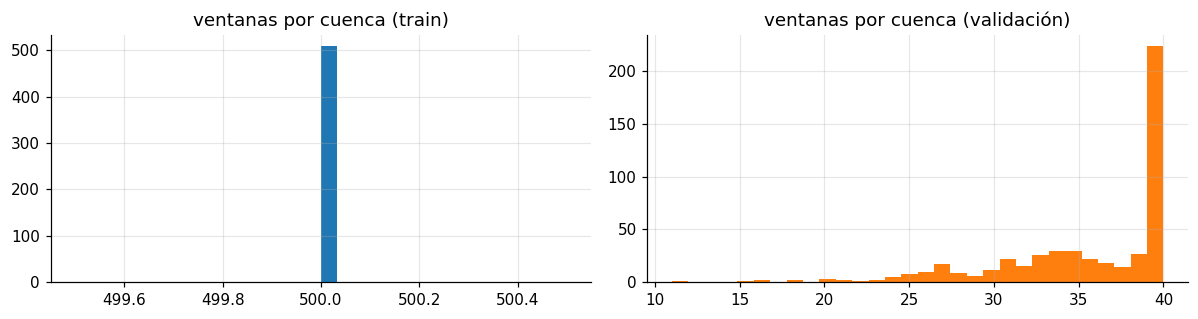

In [3]:
n_tr, n_va = (split == 0).sum(), (split == 1).sum()
print(f"train: {n_tr:,}   validación: {n_va:,}   test: {len(basin_te):,}")
print("cuencas en train:", len(np.unique(basin[split == 0])), "| en validación:", len(np.unique(basin[split == 1])),
      "| en test:", len(np.unique(basin_te)))
print("¿todas las cuencas de test aparecen en train?", np.isin(np.unique(basin_te), basin[split == 0]).all())
print("primeros 40 valores de split:", split[:40])

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(np.bincount(basin[split == 0])[np.bincount(basin[split == 0]) > 0], bins=30); ax[0].set_title("ventanas por cuenca (train)")
ax[1].hist(np.bincount(basin[split == 1])[np.bincount(basin[split == 1]) > 0], bins=30, color="C1"); ax[1].set_title("ventanas por cuenca (validación)")
plt.tight_layout(); plt.show()

**Lectura:** las 508 cuencas están en los tres conjuntos → el problema es *pronosticar el futuro de cuencas
conocidas*, no generalizar a cuencas nuevas. Esto hace **legítimo** usar el `basin_id` como entrada (un "embedding" de
cuenca; lo probamos en el notebook 04 y no mejoró). Los valores de `split` están intercalados: la validación son ventanas de las mismas
cuencas en otros momentos.

## 3. Una muestra por dentro

Usamos la clase `CaudalDataset` entregada con el dataset (`dataset/leer_datos.py`).

Id        128
X         (336, 12)
basin_id  501
y         (48,)
y_aux     (48, 11)


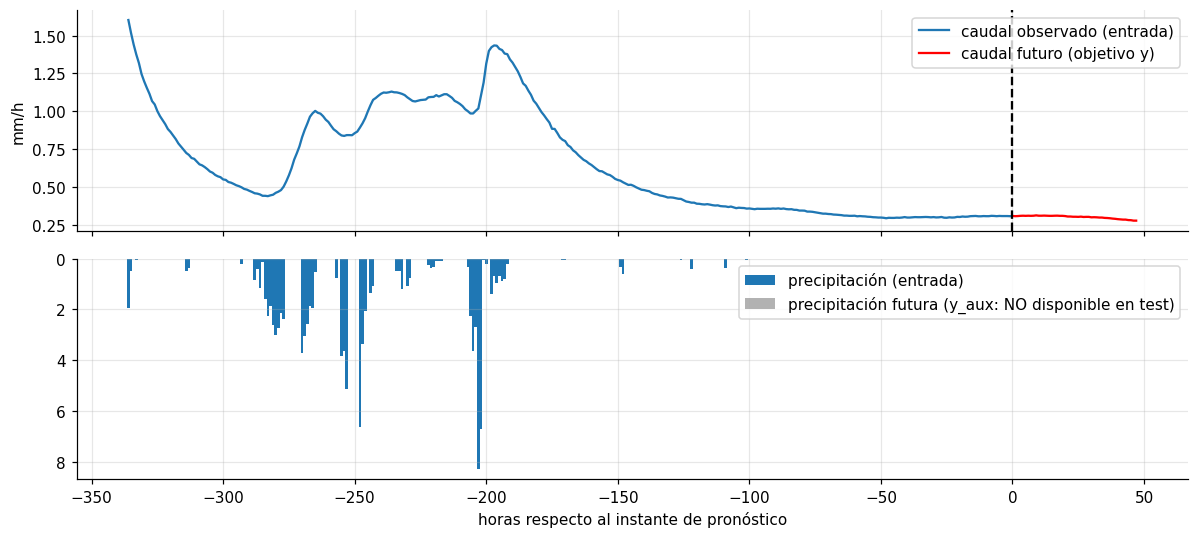

In [4]:
try:                                     # leer_datos.py viene junto al dataset del laboratorio
    from leer_datos import CaudalDataset
    ds = CaudalDataset(DATASET / "train.h5", split="train")
    s = ds[123]
except ImportError:                      # si no está, se lee la misma muestra directamente del H5
    with h5py.File(DATASET / "train.h5", "r") as f:
        i = int(np.flatnonzero(f["split"][:] == 0)[123])
        s = {"Id": i, "X": f["X"][i], "basin_id": int(f["basin_id"][i]), "y": f["y"][i], "y_aux": f["y_aux"][i]}
for k, v in s.items():
    print(f"{k:9s}", v.shape if hasattr(v, "shape") else v)

t_hist, t_fut = np.arange(-336, 0), np.arange(0, 48)
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t_hist, s["X"][:, 11], label="caudal observado (entrada)")
ax[0].plot(t_fut, s["y"], "r", label="caudal futuro (objetivo y)")
ax[0].axvline(0, color="k", ls="--"); ax[0].set_ylabel("mm/h"); ax[0].legend()
ax[1].bar(t_hist, s["X"][:, 8], width=1, label="precipitación (entrada)")
ax[1].bar(t_fut, s["y_aux"][:, 8], width=1, color="gray", alpha=.6, label="precipitación futura (y_aux: NO disponible en test)")
ax[1].invert_yaxis(); ax[1].legend(); ax[1].set_xlabel("horas respecto al instante de pronóstico")
plt.tight_layout(); plt.show()

**Idea clave:** el modelo ve 14 días (336 h) de las 12 variables y debe producir 48 valores de caudal.
La lluvia futura (`y_aux`) **no** se puede usar como entrada porque en test no existe; sólo se permite como
*supervisión auxiliar* en entrenamiento (Adapformer la usa para enseñarle al SimBlock — notebook 02).

Para el resto del EDA leemos un bloque contiguo de 20 000 ventanas (leer filas sueltas del H5 es lento: está guardado
con *chunks* de 1 muestra).

In [5]:
with h5py.File(DATASET / "train.h5", "r") as f:
    X = f["X"][:20000]; Y = f["y"][:20000]; SP = f["split"][:20000]
X, Y = X[SP == 0], Y[SP == 0]
q = X[:, :, 11]
print("bloque de EDA:", X.shape, "| NaN en X:", np.isnan(X).sum(), "| NaN en y:", np.isnan(Y).sum())
desc = pd.DataFrame({"media": X.mean((0, 1)), "std": X.std((0, 1)), "min": X.min((0, 1)),
                     "p50": np.median(X.reshape(-1, 12), 0), "p99": np.percentile(X.reshape(-1, 12), 99, 0),
                     "max": X.max((0, 1))}, index=NOMBRES)
from scipy.stats import skew
desc["asimetría"] = skew(X.reshape(-1, 12)[::50], axis=0)
desc.round(4)

bloque de EDA: (18709, 336, 12) | NaN en X: 0 | NaN en y: 0


,media,std,min,p50,p99,max,asimetría
convective_fraction,0.060500,0.198500,0.000000,0.000000,0.995800,1.000000,3.5819
longwave_radiation,313.205811,63.991299,105.436600,311.648285,453.998413,523.459229,0.0863
potential_energy,199.313202,490.357208,0.000000,0.018500,2382.519287,5815.488281,3.4021
potential_evaporation,0.204000,0.268600,-0.610500,0.068000,1.019000,1.596700,1.3858
pressure,93693.320312,8040.453613,65039.636719,96338.945312,101890.742188,104178.515625,-1.7155
shortwave_radiation,199.085205,260.366913,0.000000,19.780500,897.036316,1229.105225,1.1292
specific_humidity,0.007700,0.004400,0.000100,0.006500,0.018300,0.026600,0.6955
temperature,13.170300,9.820400,-28.457399,13.117900,34.490002,46.699501,-0.0020
total_precipitation,0.132100,0.660900,0.000000,0.000000,3.029200,76.612396,16.0348
wind_u,1.001300,3.049700,-21.027599,0.991700,8.940300,19.293900,0.2095


## 4. Colas pesadas → transformación `log1p`

El caudal y la precipitación tienen **asimetría ≈ 10–12**: la mayoría de horas son valores muy pequeños y unas
pocas horas tienen valores enormes (crecidas, tormentas). Una red entrenada con esos valores crudos estaría dominada
por los extremos y la normalización z-score quedaría distorsionada.

`log1p(x) = log(1 + x)` comprime la cola, conserva el 0 y es invertible con `expm1`.

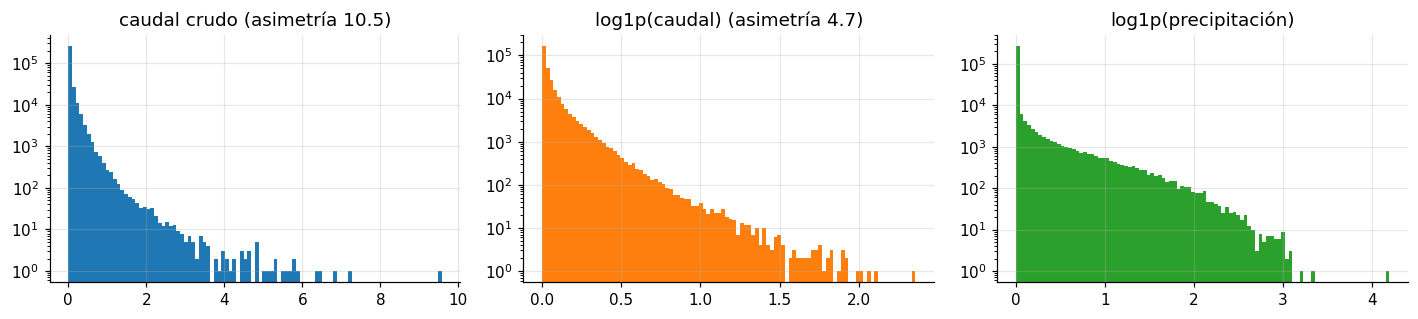

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].hist(q.ravel()[::20], bins=100); ax[0].set_yscale("log"); ax[0].set_title(f"caudal crudo (asimetría {skew(q.ravel()[::20]):.1f})")
ax[1].hist(np.log1p(q.ravel()[::20]), bins=100, color="C1"); ax[1].set_yscale("log"); ax[1].set_title(f"log1p(caudal) (asimetría {skew(np.log1p(q.ravel()[::20])):.1f})")
ax[2].hist(np.log1p(X[:, :, 8].ravel()[::20]), bins=100, color="C2"); ax[2].set_yscale("log"); ax[2].set_title("log1p(precipitación)")
plt.tight_layout(); plt.show()

> **Ojo (esto motiva un experimento del notebook 03):** `log1p` ayuda a la *entrada*, pero si además calculamos la
> **pérdida** en ese espacio, un error de 10 % en una crecida de 5 mm/h pesa lo mismo que un 10 % en un flujo base de
> 0.01 mm/h. La métrica oficial (MSE en mm/h) no piensa así. Lo retomamos en la sección 6.

## 5. Persistencia: el modelo "tonto" que hay que vencer

Persistencia = predecir que el caudal de las próximas 48 h será igual al último valor observado.
Como el caudal cambia lentamente, a corto plazo es un rival durísimo.

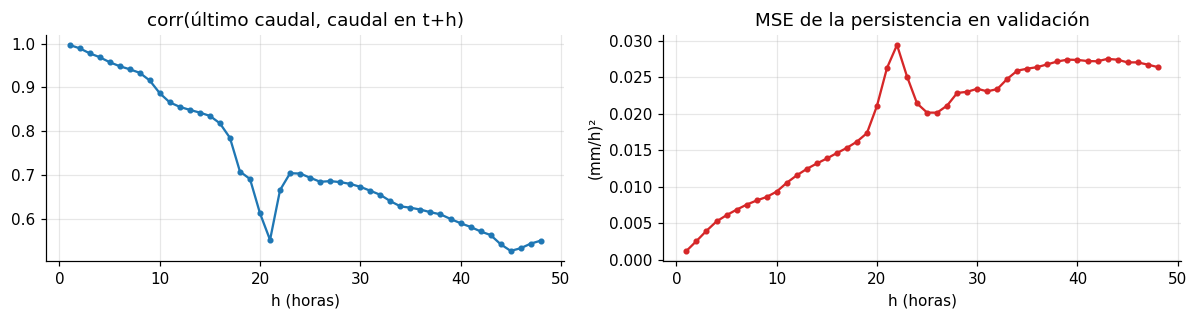

MSE persistencia (validación, todas las horas): 0.01901


In [7]:
last = q[:, -1]
corr = [np.corrcoef(last, Y[:, h])[0, 1] for h in range(48)]
with h5py.File(DATASET / "train.h5", "r") as f:
    idx_va = np.flatnonzero(split == 1)
yv = np.load(ROOT / "cache" / "y_validation.npy"); lv = np.load(ROOT / "cache" / "lastq_validation.npy")
mse_h = ((yv - lv[:, None]) ** 2).mean(0)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(range(1, 49), corr, "o-", ms=3); ax[0].set(title="corr(último caudal, caudal en t+h)", xlabel="h (horas)")
ax[1].plot(range(1, 49), mse_h, "o-", ms=3, color="C3"); ax[1].set(title="MSE de la persistencia en validación", xlabel="h (horas)", ylabel="(mm/h)²")
plt.tight_layout(); plt.show()
print(f"MSE persistencia (validación, todas las horas): {((yv - lv[:, None])**2).mean():.5f}")

**Lectura:** correlación 0.98 a 1 h pero ≈ 0.6 a 48 h. Por eso añadimos el **anclaje al último caudal**:
el modelo predice *cuánto cambia* el caudal desde el último valor, en lugar del valor absoluto. Así a 1 h ya parte de la
persistencia y el aprendizaje se concentra en el cambio.

## 6. ¿Dónde está el error? (la observación que motiva probar otra pérdida)

Medimos qué fracción del error cuadrático total de la persistencia viene del 10 % de ventanas con caudal futuro más alto.

umbral de 'crecida' (p90 del máximo futuro): 0.230 mm/h
el 10 % de ventanas con crecida aporta el 98.7 % del MSE


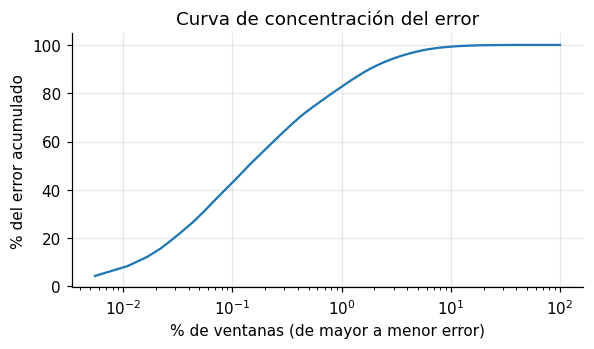

In [8]:
sse_vent = ((yv - lv[:, None]) ** 2).sum(1)
ymax = yv.max(1); thr = np.quantile(ymax, .9)
print(f"umbral de 'crecida' (p90 del máximo futuro): {thr:.3f} mm/h")
print(f"el 10 % de ventanas con crecida aporta el {100 * sse_vent[ymax > thr].sum() / sse_vent.sum():.1f} % del MSE")
orden = np.sort(sse_vent)[::-1]
plt.figure(figsize=(6, 3)); plt.plot(np.arange(1, len(orden) + 1) / len(orden) * 100, np.cumsum(orden) / orden.sum() * 100)
plt.xscale("log"); plt.xlabel("% de ventanas (de mayor a menor error)"); plt.ylabel("% del error acumulado"); plt.title("Curva de concentración del error"); plt.show()

**Conclusión crucial:** el MSE en mm/h lo deciden casi por completo las crecidas (~98 %). Un modelo entrenado
minimizando el error en espacio `log` "no se entera" de esto: le da el mismo peso a cada ventana. Por eso
**probamos** una **pérdida híbrida** = MSE en log (cuida cuencas pequeñas → NSE) + λ·MSE en mm/h
(cuida crecidas → MSE). Resultado (notebooks 03 y 04): no mejoró, y el modelo final usa la pérdida en log.

## 7. Relación entre canales (motivación de Adapformer)

Adapformer parte de la hipótesis de que **no todos los canales ayudan a predecir un objetivo** y que conviene
*seleccionar* los relevantes por muestra. Calculamos la correlación media 12×12 dentro de cada ventana (esto es,
justamente, lo que hace el SimBlock: `W = XᵀX/T`).

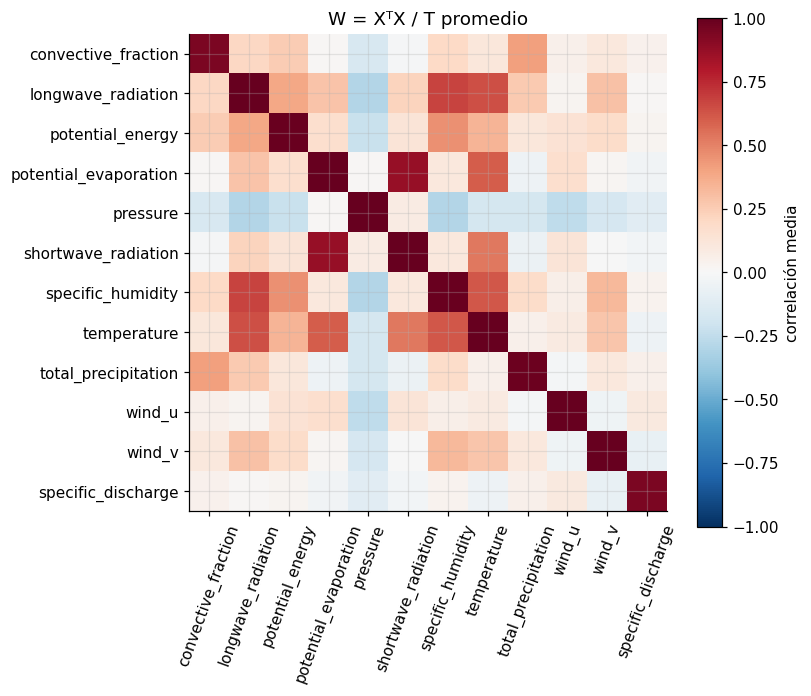

correlación del caudal con cada canal:
pressure                -0.112
wind_v                  -0.073
temperature             -0.053
potential_evaporation   -0.031
shortwave_radiation     -0.024
longwave_radiation       0.014
potential_energy         0.027
specific_humidity        0.036
convective_fraction      0.045
total_precipitation      0.047
wind_u                   0.101
specific_discharge       0.940
dtype: float32


In [9]:
Xl = X[::4].copy(); Xl[..., [8, 11]] = np.log1p(np.clip(Xl[..., [8, 11]], 0, None))
Z = (Xl - Xl.mean(1, keepdims=True)) / (Xl.std(1, keepdims=True) + 1e-5)        # normalización por ventana (≈ RevIN)
C = np.einsum("btn,btm->nm", Z, Z) / (Z.shape[0] * Z.shape[1])
plt.figure(figsize=(7, 6)); plt.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1); plt.colorbar(label="correlación media")
plt.xticks(range(12), NOMBRES, rotation=70); plt.yticks(range(12), NOMBRES); plt.title("W = XᵀX / T promedio"); plt.show()
print("correlación del caudal con cada canal:"); print(pd.Series(C[11], index=NOMBRES).round(3).sort_values())

**Lectura:** las variables meteorológicas se relacionan fuertemente entre sí (radiación–temperatura–humedad),
pero el caudal se relaciona **débilmente** con todas (|r| ≈ 0.1). Esto anticipa un resultado de la ablación: con sólo
12 canales y un objetivo dominado por su propia memoria, *la selección top-k tiene poco margen de mejora*.

## 8. Respuesta retardada a la lluvia

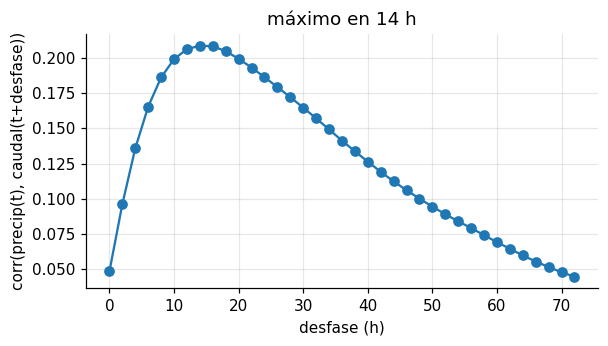

In [10]:
lags = np.arange(0, 73, 2)
pr = np.log1p(X[::4, :, 8]); qq = np.log1p(X[::4, :, 11])
pr = (pr - pr.mean(1, keepdims=True)) / (pr.std(1, keepdims=True) + 1e-6)
qq = (qq - qq.mean(1, keepdims=True)) / (qq.std(1, keepdims=True) + 1e-6)
xc = [np.mean(pr[:, : 336 - L] * qq[:, L:]) for L in lags]
plt.figure(figsize=(6, 3)); plt.plot(lags, xc, "o-"); plt.xlabel("desfase (h)"); plt.ylabel("corr(precip(t), caudal(t+desfase))")
plt.title(f"máximo en {lags[int(np.argmax(xc))]} h"); plt.show()

La cuenca responde a la lluvia con **≈ 10–15 h de retraso** y de forma difusa. Consecuencia: la lluvia de las
últimas horas de la ventana sí ayuda a predecir las primeras horas del horizonte, pero la relación es débil y muy variable:
la misma lluvia produce una crecida en unas condiciones y no en otras (humedad del suelo, intensidad). Y una crecida
provocada por lluvia que **todavía no ha caído** es imposible de anticipar. El notebook 05 mide cuánto pesa cada caso.

## Resumen de decisiones

| Hallazgo | Decisión |
|---|---|
| Sin NaN | Sin imputación (sólo `nan_to_num` defensivo) |
| Caudal y precipitación con asimetría ≈ 11 | `log1p` en canales 8 y 11 + z-score con estadísticas de **train** |
| Persistencia muy fuerte a 1 h | Baseline de persistencia + anclaje al último caudal |
| 98 % del MSE en crecidas | Reportar también NSE/KGE por cuenca; se probó una pérdida híbrida log + mm/h (descartada) |
| Las 508 cuencas están en test | Se probó un embedding de cuenca (descartado, notebook 04) |
| Caudal poco correlacionado con el resto | La selección top-k tiene poco margen; en la ablación el mejor fue k = 12 |